<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model

- Given the high prevalence of missing values and the likely non-linear relationships between features and the target, a boosting-based approach is well suited for this problem. I chose XGBoost due to its strong track record in handling imbalanced classification tasks and its flexibility in capturing complex, non-linear patterns.

- A common alternative in credit risk modeling is Logistic Regression; however, in its standard form it assumes linear decision boundaries. Given the observed feature behavior, this assumption is likely too restrictive for this dataset (though not formally tested here).

- The model is optimized using `log_loss`, while hyperparameter tuning is guided by `PR-AUC`, which is more appropriate for highly imbalanced datasets.

- This approach provides several advantages:
  - ability to model non-linear relationships  
  - native handling of missing values without requiring imputation  
  - robustness to multicollinearity among features  

- Model performance on the test set is moderate. In the context of risk scoring, correctly identifying positive cases (defaults) is typically more critical than minimizing false positives. Therefore, Recall is considered more important than Precision in this setting.



- Categorical features with NaNs
    - account_status,
    - account_worst_status_0_3m,
    - account_worst_status_12_24m,
    - account_worst_status_3_6m,
    - account_worst_status_6_12m,
    - num_arch_written_off_0_12m,
    - num_arch_written_off_12_24m,
    - worst_status_active_inv

- Categorical features no NaNs
    - merchant_category,
    - merchant_group,
    - has_paid,
    - name_in_email,
    - num_arch_dc_0_12m,
    - num_arch_dc_12_24m,
    - status_last_archived_0_24m, 
    - status_2nd_last_archived_0_24m,
    - status_3rd_last_archived_0_24m,
    - status_max_archived_0_6_months',
    - status_max_archived_0_12_months,
    - status_max_archived_0_24_months

- Numerical features with NaNs
    - account_days_in_dc_12_24m,
    - account_days_in_rem_12_24m,
    - account_days_in_term_12_24m,
    - account_incoming_debt_vs_paid_0_24m,
    - avg_payment_span_0_12m,
    - avg_payment_span_0_3m,
    - num_active_div_by_paid_inv_0_12m

- Numerical features no NaNs
    - account_amount_added_12_24m,
    - age,
    - max_paid_inv_0_12m,
    - max_paid_inv_0_24m,
    - num_active_inv,
    - num_arch_ok_0_12m,
    - num_arch_ok_12_24m,
    - num_arch_rem_0_12m,
    - num_unpaid_bills,
    - recovery_debt,
    - sum_capital_paid_account_0_12m,
    - sum_capital_paid_account_12_24m,
    - sum_paid_inv_0_12m,
    - time_hours

</div>

#### Load Data

In [ ]:


import joblib
import shap 
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import warnings
import category_encoders as ce
from statsmodels.stats.proportion import proportions_ztest
from sklearn.metrics import roc_auc_score, recall_score, precision_score, average_precision_score, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import category_encoders as ce
from xgboost import XGBClassifier

import utils
import preprocessing
import importlib

importlib.reload(utils)
from utils import evaluate_and_report, evaluate_nn, plot_confusion_matrix

importlib.reload(preprocessing)
from preprocessing import QuantileBinner


from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

import category_encoders as ce


mlflow.set_experiment("credit-risk-models")
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)
pd.options.display.float_format = '{:.5f}'.format



df = pd.read_csv("./dataset.csv", sep = ";")
df['has_paid'] = df['has_paid'].astype(int)

df_nna = df[df['default'].notna()]  # observations for which we have default values (Training + Validation set)
#df_na = df[df['default'].isna()]    # observations for which we dont have default values (Unlabeled data)

X = df_nna.drop(columns=["default"])
y = df_nna["default"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, stratify=y, test_size=0.2, random_state=42
# )


# 1. split off TEST (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.10,
    stratify=y,
    random_state=42
)

# 2. split remaining into TRAIN (70%) and VAL (20%)
# 20 / 90 ≈ 0.2222
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2222,
    stratify=y_temp,
    random_state=42
)


<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model 1: Logistic regression V1
- Numerical features
    - account_days_in_dc_12_24m -             only 11% NAs, 0 is the median - impute median
    - account_days_in_rem_12_24m -            only 11% NAs, 0 is the median - impute median
    - account_days_in_term_12_24m -           only 11% NAs, 0 is the median - impute median
    - account_incoming_debt_vs_paid_0_24m -   assign it median or -999
    - avg_payment_span_0_3m -                 assign it median or -999
    - avg_payment_span_0_12m -                assign it median or -999
    - num_active_div_by_paid_inv_0_12m -      assign it median or -999

- For each numerical feature with NaNs, a "_missing" column is made indicating where the value was imputed
- All numerical features are standardized
    
- Categorical features
    - account_satus -               Categorical, make NA a new category -> target encoding
    - account_worst_status_0_3m -   Categorical, make NA a new category -> target encoding
    - account_worst_status_12_24m - Categorical, make NA a new category -> target encoding
    - account_worst_status_3_6m -   Categorical, make NA a new category -> target encoding
    - account_worst_status_6_12m -  Categorical, make NA a new category -> target encoding
    - num_arch_written_off_0_12m -  Categorical, make NA a new category -> target encoding
    - num_arch_written_off_12_24m - Categorical, make NA a new category -> target encoding
    - worst_status_active_inv -     Categorical, make NA a new category -> target encoding



</div>

Fitting 5 folds for each of 10 candidates, totalling 50 fits


2026/04/04 12:01:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Best CV average_precision: 0.16079004316464662

Best Parameters:
clf__C: 0.1668100537200059

Test ROC AUC: 0.8930428367127867
Test PR AUC: 0.1489193330696014
Precision: 0.05739760378935636
Recall: 0.7984496124031008

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   14353    3383
Actual 1      52     206


2026/04/04 12:01:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


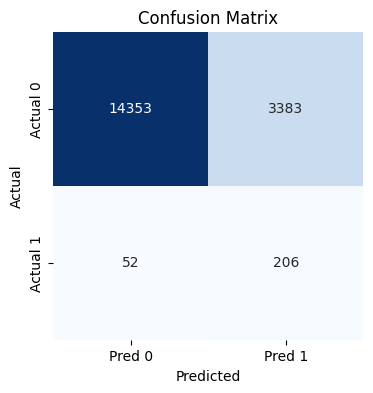

In [ ]:

# -------------------------
# FEATURE GROUPS
# -------------------------

cat_na_columns = [
    'account_status', 
    'account_worst_status_0_3m', 
    'account_worst_status_12_24m',
    'account_worst_status_3_6m', 
    'account_worst_status_6_12m',
    'num_arch_written_off_0_12m', 
    'num_arch_written_off_12_24m',
    'worst_status_active_inv'
]

cat_no_na_columns = [
    'merchant_category', 
    'merchant_group', 
    'has_paid', 
    'name_in_email',
    'num_arch_dc_0_12m', 
    'num_arch_dc_12_24m',
    'status_last_archived_0_24m', 
    'status_2nd_last_archived_0_24m',
    'status_3rd_last_archived_0_24m',
    'status_max_archived_0_6_months', 
    'status_max_archived_0_12_months',
    'status_max_archived_0_24_months'
]

num_na_columns = [
    'account_days_in_dc_12_24m', 
    'account_days_in_rem_12_24m',
    'account_days_in_term_12_24m', 
    'account_incoming_debt_vs_paid_0_24m',
    'avg_payment_span_0_12m', 
    'avg_payment_span_0_3m',
    'num_active_div_by_paid_inv_0_12m'
]

num_no_na_columns = [
    'account_amount_added_12_24m', 
    'age', 
    'max_paid_inv_0_12m',
    'max_paid_inv_0_24m', 
    'num_active_inv', 
    'num_arch_ok_0_12m',
    'num_arch_ok_12_24m', 
    'num_arch_rem_0_12m', 
    'num_unpaid_bills',
    'recovery_debt', 
    'sum_capital_paid_account_0_12m',
    'sum_capital_paid_account_12_24m', 
    'sum_paid_inv_0_12m',
    'time_hours'
]


all_cat_cols = cat_na_columns + cat_no_na_columns
all_num_cols = num_na_columns + num_no_na_columns
feature_cols = all_cat_cols + all_num_cols

# =========================
# KEEP ONLY MODEL FEATURES
# =========================

X_train_lr1 = X_train[feature_cols].copy()
X_val_lr1 = X_val[feature_cols].copy()
#X_test_lr1 = X_test[feature_cols].copy()

# -------------------------
# CREATE MISSING INDICATORS (IMPORTANT STEP)
# -------------------------

def add_missing_indicators(df, num_na_cols):
    df = df.copy()
    for col in num_na_cols:
        df[f"{col}_missing"] = df[col].isna().astype(int)
    return df

X_train_lr1 = add_missing_indicators(X_train_lr1, num_na_columns)
X_val_lr1 = add_missing_indicators(X_val_lr1, num_na_columns)

# indicator columns
num_indicator_columns = [f"{col}_missing" for col in num_na_columns]

# -------------------------
# PIPELINES
# -------------------------

# numeric with NA → impute + scale
num_na_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# numeric without NA → scale
num_no_na_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# indicators → passthrough (NO scaling!)
indicator_pipeline = Pipeline([
    ("passthrough", "passthrough")
])

# categorical → impute + WoE
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("woe", ce.WOEEncoder(handle_missing='value', handle_unknown='value'))
])

# -------------------------
# PREPROCESSOR
# -------------------------

preprocessor = ColumnTransformer([
    ("num_na", num_na_pipeline, num_na_columns),
    ("num_no_na", num_no_na_pipeline, num_no_na_columns),
    ("indicators", indicator_pipeline, num_indicator_columns),
    ("cat_woe", cat_pipeline, all_cat_cols),
])

# -------------------------
# MODEL
# -------------------------

model = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", LogisticRegression(
        #penalty="l2",
        #solver="lbfgs",
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced"
    ))
])

# -------------------------
# HYPERPARAMETERS
# -------------------------

param_dist = {
    "clf__C": np.logspace(-3, 2, 10),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_lr1 = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)



with mlflow.start_run(run_name="logreg_v1"):
   
    random_search_lr1.fit(X_train_lr1, y_train)  # TRAIN
    results = evaluate_and_report(random_search_lr1, X_val_lr1, y_val, threshold=0.5, ) # EVALUATE

    # =========================
    # LOG BEST PARAMS
    # =========================

    mlflow.log_input(
        mlflow.data.from_pandas(X_val_lr1.head(1000), name="val_sample"),
        context="validation"
        )

    mlflow.log_params(random_search_lr1.best_params_)
    mlflow.log_param("model_type", "logistic_regression")
    mlflow.log_param("penalty", "l1")
    mlflow.log_param("solver", "liblinear")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("scoring", "average_precision")
    mlflow.log_param("threshold", 0.5)
    
    
    # =========================
    # LOG METRICS
    # =========================
    results_without_cm = {k: float(v) for k, v in results.items() if k != "confusion_matrix"}
    mlflow.log_metrics(results_without_cm)

    cm = results["confusion_matrix"]
    fig = plot_confusion_matrix(cm)
    mlflow.log_figure(fig, "confusion_matrix_normalized.png")
    
    # =========================
    # LOG MODEL
    # =========================
    mlflow.sklearn.log_model(
            random_search_lr1.best_estimator_,
            artifact_path="model",
            input_example=X_val_lr1.head(5)
    )

In [47]:
evaluate_and_report(random_search_lr1, X_val_lr1, y_val, threshold=0.8, metric="average_precision")

Best CV average_precision: 0.16078993324959856

Best Parameters:
clf__C: 0.1668100537200059

Test ROC AUC: 0.8930428367127867
Test PR AUC: 0.1489193330696014
Precision: 0.13034623217922606
Recall: 0.49612403100775193

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   16882     854
Actual 1     130     128


{'roc_auc': 0.8930428367127867,
 'pr_auc': 0.1489193330696014,
 'precision': 0.13034623217922606,
 'recall': 0.49612403100775193,
 'confusion_matrix': array([[16882,   854],
        [  130,   128]])}

In [48]:
X_test_lr1 = X_test[feature_cols].copy()
X_test_lr1 = add_missing_indicators(X_test_lr1, num_na_columns)

best_model = random_search_lr1.best_estimator_

def predict_single(model, X, y, idx, threshold = 0.5):
    x = X.iloc[[idx]]
    y_true = y.iloc[idx]
    
    prob = model.predict_proba(x)[0, 1]
    pred = int(prob >= threshold)
    
    print(f"Prediction: {pred}")
    print(f"Probability: {prob:.4f}")
    print(f"Actual: {y_true}")
    
    return prob, pred, y_true

predict_single(best_model, X_test_lr1, y_test, idx=15)

Prediction: 0
Probability: 0.0626
Actual: 0.0


(0.06262837740342972, 0, 0.0)

<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model 2: Log Regression
- Numerical features -> median impute for NaNs + binning + WoE Encoding
- Categorical features -> WoE Encoding

- Potential improvements
    - monotonic binning
    - Add ratios
    - Log transforms
    - Caps - winsorization
    - try L1
    - interaction features
    - change class weight -> class_weight={0:1, 1:2}

X["debt_to_paid"] = X["recovery_debt"] / (X["sum_paid_inv_0_12m"] + 1)
X["active_to_paid"] = X["num_active_inv"] / (X["sum_paid_inv_0_12m"] + 1)

X["log_recovery_debt"] = np.log1p(X["recovery_debt"])

X["recovery_debt"] = X["recovery_debt"].clip(upper=X["recovery_debt"].quantile(0.99))

X["debt_x_active"] = X["recovery_debt"] * X["num_active_inv"]

</div>

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best CV average_precision: 0.15260853189070736

Best Parameters:
clf__C: 100.0


2026/04/04 12:19:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Test ROC AUC: 0.8963654704835433
Test PR AUC: 0.13056090487754868
Precision: 0.057687074829931975
Recall: 0.8217054263565892

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   14273    3463
Actual 1      46     212


2026/04/04 12:19:38 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


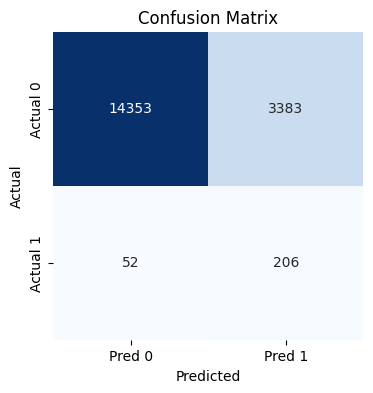

In [52]:

# -------------------------
# FEATURE GROUPS
# -------------------------

cat_na_columns = [
    'account_status',
    'account_worst_status_0_3m',
    'account_worst_status_12_24m',
    'account_worst_status_3_6m',
    'account_worst_status_6_12m',
    'num_arch_written_off_0_12m',
    'num_arch_written_off_12_24m',
    'worst_status_active_inv'
]

cat_no_na_columns = [
    'merchant_category',
    'merchant_group',
    'has_paid',
    'name_in_email',
    'num_arch_dc_0_12m',
    'num_arch_dc_12_24m',
    'status_last_archived_0_24m',
    'status_2nd_last_archived_0_24m',
    'status_3rd_last_archived_0_24m',
    'status_max_archived_0_6_months',
    'status_max_archived_0_12_months',
    'status_max_archived_0_24_months'
]

num_na_columns = [
    'account_days_in_dc_12_24m',
    'account_days_in_rem_12_24m',
    'account_days_in_term_12_24m',
    'account_incoming_debt_vs_paid_0_24m',
    'avg_payment_span_0_12m',
    'avg_payment_span_0_3m',
    'num_active_div_by_paid_inv_0_12m'
]

num_no_na_columns = [
    'account_amount_added_12_24m',
    'age',
    'max_paid_inv_0_12m',
    'max_paid_inv_0_24m',
    'num_active_inv',
    'num_arch_ok_0_12m',
    'num_arch_ok_12_24m',
    'num_arch_rem_0_12m',
    'num_unpaid_bills',
    'recovery_debt',
    'sum_capital_paid_account_0_12m',
    'sum_capital_paid_account_12_24m',
    'sum_paid_inv_0_12m',
    'time_hours'
]

all_cat_cols = cat_na_columns + cat_no_na_columns
all_num_cols = num_na_columns + num_no_na_columns
feature_cols = all_cat_cols + all_num_cols


# =========================
# KEEP ONLY MODEL FEATURES
# =========================

X_train_lr2 = X_train[feature_cols].copy()
X_val_lr2 = X_val[feature_cols].copy()


# -------------------------
# CREATE MISSING INDICATORS
# -------------------------

def add_missing_indicators(df, num_na_cols):
    df = df.copy()
    for col in num_na_cols:
        df[f"{col}_missing"] = df[col].isna().astype(int)
    return df

X_train_lr2 = add_missing_indicators(X_train_lr2, num_na_columns)
X_val_lr2 = add_missing_indicators(X_val_lr2, num_na_columns)

num_indicator_columns = [f"{col}_missing" for col in num_na_columns]


# -------------------------
# PIPELINES
# -------------------------

# numeric with NA -> impute -> bin -> WoE
num_na_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("binning", QuantileBinner(n_bins=5)),
    ("woe", ce.WOEEncoder(handle_missing="value", handle_unknown="value"))
])

# numeric without NA -> bin -> WoE
num_no_na_pipeline = Pipeline([
    ("binning", QuantileBinner(n_bins=5)),
    ("woe", ce.WOEEncoder(handle_missing="value", handle_unknown="value"))
])

# indicators -> passthrough
indicator_pipeline = "passthrough"

# categorical -> impute -> WoE
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("woe", ce.WOEEncoder(handle_missing="value", handle_unknown="value"))
])


# -------------------------
# PREPROCESSOR
# -------------------------

preprocessor = ColumnTransformer([
    ("num_na", num_na_pipeline, num_na_columns),
    ("num_no_na", num_no_na_pipeline, num_no_na_columns),
    ("indicators", indicator_pipeline, num_indicator_columns),
    ("cat_woe", cat_pipeline, all_cat_cols),
])


# -------------------------
# MODEL
# -------------------------

model = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced"
    ))
])


# -------------------------
# HYPERPARAMETERS
# -------------------------

param_dist = {
    "clf__C": np.logspace(-3, 2, 10),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_lr2 = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    error_score="raise"
)

# -------------------------
# TRAIN
# -------------------------
with mlflow.start_run(run_name="logreg_v2"):

    random_search_lr2.fit(X_train_lr2, y_train.to_numpy()) #FIT
    evaluate_and_report(random_search_lr2, X_val_lr2, y_val.to_numpy(), threshold=0.5) #EVALUATE


    mlflow.set_tag("encoding", "woe + quantile_binning")   

    mlflow.set_tag("model_summary", 
    "Logistic regression with WoE encoding and quantile binning (credit risk)")

    mlflow.log_input(
        mlflow.data.from_pandas(X_val_lr2.head(1000), name="val_sample"),
        context="validation"
        )

    mlflow.log_params(random_search_lr1.best_params_)
    mlflow.log_param("model_type", "logistic_regression")
    mlflow.log_param("penalty", "l1")
    mlflow.log_param("solver", "liblinear")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("scoring", "average_precision")
    mlflow.log_param("threshold", 0.5)
    
    # =========================
    # LOG METRICS
    # =========================
    results_without_cm = {k: float(v) for k, v in results.items() if k != "confusion_matrix"}
    mlflow.log_metrics(results_without_cm)

    cm = results["confusion_matrix"]
    fig = plot_confusion_matrix(cm)
    mlflow.log_figure(fig, "confusion_matrix_normalized.png")
    
    # =========================
    # LOG MODEL
    # =========================
    mlflow.sklearn.log_model(
            random_search_lr2.best_estimator_,
            artifact_path="model",
            input_example=X_val_lr2.head(5)
    )
    

In [ ]:
evaluate_and_report(random_search_lr2, X_val_lr2, y_val.to_numpy(), threshold=0.8)

In [ ]:
X_test_lr2 = X_test[feature_cols].copy()
X_test_lr2 = add_missing_indicators(X_test_lr2, num_na_columns)

best_model = random_search_lr2.best_estimator_

predict_single(best_model, X_test_lr2, y_test, idx=300)

<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model 3: XGBoost
- No feature manipulation

</div>

In [ ]:

# =========================
# FEATURE GROUPS
# =========================

cat_na_cols = [
    "account_status",
    "account_worst_status_0_3m",
    "account_worst_status_12_24m",
    "account_worst_status_3_6m",
    "account_worst_status_6_12m",
    "num_arch_written_off_0_12m",
    "num_arch_written_off_12_24m",
    "worst_status_active_inv",
]

cat_no_na_cols = [
    "merchant_category",
    "merchant_group",
    "has_paid",
    "name_in_email",
    "num_arch_dc_0_12m",
    "num_arch_dc_12_24m",
    "status_last_archived_0_24m",
    "status_2nd_last_archived_0_24m",
    "status_3rd_last_archived_0_24m",
    "status_max_archived_0_6_months",
    "status_max_archived_0_12_months",
    "status_max_archived_0_24_months",
]

num_na_cols = [
    "account_days_in_dc_12_24m",
    "account_days_in_rem_12_24m",
    "account_days_in_term_12_24m",
    "account_incoming_debt_vs_paid_0_24m",
    "avg_payment_span_0_12m",
    "avg_payment_span_0_3m",
    "num_active_div_by_paid_inv_0_12m",
]

num_no_na_cols = [
    "account_amount_added_12_24m",
    "age",
    "max_paid_inv_0_12m",
    "max_paid_inv_0_24m",
    "num_active_inv",
    "num_arch_ok_0_12m",
    "num_arch_ok_12_24m",
    "num_arch_rem_0_12m",
    "num_unpaid_bills",
    "recovery_debt",
    "sum_capital_paid_account_0_12m",
    "sum_capital_paid_account_12_24m",
    "sum_paid_inv_0_12m",
    "time_hours",
]

all_cat_cols = cat_na_cols + cat_no_na_cols
all_num_cols = num_na_cols + num_no_na_cols
feature_cols = all_cat_cols + all_num_cols

# =========================
# KEEP ONLY MODEL FEATURES
# =========================

X_train_xgb1 = X_train[feature_cols].copy()
X_val_xgb1 = X_val[feature_cols].copy()
# =========================
# CAST CATEGORICAL COLUMNS
# =========================

for col in all_cat_cols:
    X_train_xgb1[col] = X_train_xgb1[col].astype("category")
    X_val_xgb1[col] = X_val_xgb1[col].astype("category")
    X_val_xgb1[col] = X_val_xgb1[col].cat.set_categories(
        X_train_xgb1[col].cat.categories
    )

# =========================
# CLASS IMBALANCE
# =========================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# =========================
# MODEL
# =========================

model = XGBClassifier(
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    enable_categorical=True,
    tree_method="hist",
)

# =========================
# HYPERPARAMETERS
# =========================

param_dist = {
    "n_estimators": [200, 300, 500, 1000],
    "max_depth": [3, 5, 8],
    "learning_rate": [0.01, 0.02, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": np.linspace(0, 2, 5),
    "min_child_weight": [1, 3, 5, 10],
    "reg_lambda": np.linspace(0, 3, 5),
    "reg_alpha": np.linspace(0, 3, 5),
}

# =========================
# CROSS-VALIDATION
# =========================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_xgb1 = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    error_score="raise",
)

# =========================
# TRAIN
# =========================

random_search_xgb1.fit(X_train_xgb1, y_train)

# =========================
# EVALUATE
# =========================

evaluate_and_report(
    random_search_xgb1,
    X_val_xgb1,
    y_val,
    threshold=0.5,
    metric="average_precision",
)

In [ ]:
evaluate_and_report( random_search_xgb1, X_val_xgb1, y_val, threshold=0.37, metric="average_precision")

In [ ]:
X_test_xgb1 = X_test[feature_cols].copy()

for col in all_cat_cols:
    X_test_xgb1[col] = X_test_xgb1[col].astype("category")
    X_test_xgb1[col] = X_test_xgb1[col].cat.set_categories(
        X_train_xgb1[col].cat.categories
    )

best_model = random_search_xgb1.best_estimator_

predict_single(best_model, X_test_xgb1, y_test, idx=10)

<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model 4: XGBoost
- WoE Encoding for categorical and numerical values with NaNs 

</div>

In [ ]:


cat_na_cols = [
    "account_status",
    "account_worst_status_0_3m",
    "account_worst_status_12_24m",
    "account_worst_status_3_6m",
    "account_worst_status_6_12m",
    "num_arch_written_off_0_12m",
    "num_arch_written_off_12_24m",
    "worst_status_active_inv",
]

cat_no_na_cols = [
    "merchant_category",
    "merchant_group",
    "has_paid",
    "name_in_email",
    "num_arch_dc_0_12m",
    "num_arch_dc_12_24m",
    "status_last_archived_0_24m",
    "status_2nd_last_archived_0_24m",
    "status_3rd_last_archived_0_24m",
    "status_max_archived_0_6_months",
    "status_max_archived_0_12_months",
    "status_max_archived_0_24_months",
]

num_na_cols = [
    "account_days_in_dc_12_24m",
    "account_days_in_rem_12_24m",
    "account_days_in_term_12_24m",
    "account_incoming_debt_vs_paid_0_24m",
    "avg_payment_span_0_12m",
    "avg_payment_span_0_3m",
    "num_active_div_by_paid_inv_0_12m",
]

num_no_na_cols = [
    "account_amount_added_12_24m",
    "age",
    "max_paid_inv_0_12m",
    "max_paid_inv_0_24m",
    "num_active_inv",
    "num_arch_ok_0_12m",
    "num_arch_ok_12_24m",
    "num_arch_rem_0_12m",
    "num_unpaid_bills",
    "recovery_debt",
    "sum_capital_paid_account_0_12m",
    "sum_capital_paid_account_12_24m",
    "sum_paid_inv_0_12m",
    "time_hours",
]

all_cat_cols = cat_na_cols + cat_no_na_cols
all_num_cols = num_na_cols + num_no_na_cols
feature_cols = all_cat_cols + all_num_cols

# =========================
# KEEP ONLY MODEL FEATURES
# =========================

X_train_xgb2 = X_train[feature_cols].copy()
X_val_xgb2 = X_val[feature_cols].copy()

# IDENTIFY COLUMNS

na_columns = X_train_xgb2.columns[X_train_xgb2.isna().any()].tolist()

numeric_columns = X_train_xgb2.select_dtypes(include=np.number).columns.tolist()
cat_columns = [col for col in X_train_xgb2.columns if col not in numeric_columns]

num_na_columns = [col for col in na_columns if col in numeric_columns]
num_no_na_columns = [col for col in numeric_columns if col not in num_na_columns]


# PIPELINES

# numeric with NA → bin + WoE
num_na_pipeline = Pipeline([
    ("binning", QuantileBinner(n_bins=10)),
    ("woe", ce.WOEEncoder(handle_unknown='value', handle_missing='value'))
])

# numeric without NA → passthrough
num_pipeline = Pipeline([
    ("passthrough", "passthrough")
])

# categorical → WoE (NA handled internally)
cat_pipeline = Pipeline([
    ("encoder", ce.WOEEncoder(handle_unknown='value', handle_missing='value'))
])

preprocessor = ColumnTransformer([
    ("num_na_woe", num_na_pipeline, num_na_columns),
    ("num", num_pipeline, num_no_na_columns),
    ("cat_woe", cat_pipeline, cat_columns),
])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", XGBClassifier(
        #eval_metric="auc",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        use_label_encoder=False
    ))
])

param_dist = {
    "clf__n_estimators": [200,300,500,1000],
    "clf__max_depth": [3, 5, 8],
    "clf__learning_rate": [0.01, 0.02, 0.05, 0.1],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "clf__gamma": np.linspace(0, 2, 5),
    "clf__min_child_weight": [1, 3, 5, 10],
    "clf__reg_lambda": np.linspace(0, 3, 5),
    "clf__reg_alpha": np.linspace(0, 3, 5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_xgb2 = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    #scoring="roc_auc",
    scoring="average_precision",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# MODEL TRAINING
random_search_xgb2.fit(X_train, y_train)

evaluate_and_report(random_search_xgb2, X_val_xgb2, y_val, threshold=0.5, metric="average_precision")

In [ ]:
evaluate_and_report(random_search_xgb2, X_val_xgb2, y_val, threshold=0.4, metric="average_precision")

In [ ]:
X_test_xgb2 = X_test[feature_cols].copy()

best_model = random_search_xgb2.best_estimator_

predict_single(best_model, X_test_xgb2, y_test, idx=10)

<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model 5: Deep Neural Network
- Median inpute for NaNs of numerical features
- Numerical features are standardized
- Categorical features are encoded

</div>

In [ ]:
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

# =========================
# 0. SEED (IMPORTANT)
# =========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =========================
# 1. COPY DATA
# =========================

X_train_nn1 = X_train.copy()
X_val_nn1 = X_val.copy()

# =========================
# 2. DEFINE COLUMNS
# =========================

cat_columns = cat_na_columns + cat_no_na_columns
num_columns = num_na_columns + num_no_na_columns

# =========================
# 3. ENCODE CATEGORICALS
# =========================

cat_encoders = {}

for col in cat_columns:
    X_train_nn1[col] = X_train_nn1[col].astype(str).fillna("MISSING")
    X_val_nn1[col] = X_val_nn1[col].astype(str).fillna("MISSING")
    
    unique_vals = sorted(X_train_nn1[col].unique().tolist())
    
    if "MISSING" not in unique_vals:
        unique_vals.append("MISSING")
    
    encoder = {val: i for i, val in enumerate(unique_vals)}
    
    X_train_nn1[col] = X_train_nn1[col].map(encoder).astype(int)
    X_val_nn1[col] = X_val_nn1[col].map(
        lambda x: encoder.get(x, encoder["MISSING"])
    ).astype(int)
    
    cat_encoders[col] = encoder

# =========================
# 4. NUMERICAL PREPROCESSING
# =========================

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_nn1[num_columns] = imputer.fit_transform(X_train_nn1[num_columns])
X_val_nn1[num_columns] = imputer.transform(X_val_nn1[num_columns])

X_train_nn1[num_columns] = scaler.fit_transform(X_train_nn1[num_columns])
X_val_nn1[num_columns] = scaler.transform(X_val_nn1[num_columns])

# =========================
# 5. DATASET
# =========================

class TabularDataset(Dataset):
    def __init__(self, X, y, cat_cols, num_cols):
        self.X_cat = torch.tensor(X[cat_cols].values, dtype=torch.long)
        self.X_num = torch.tensor(X[num_cols].values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]

# =========================
# 6. DATALOADERS
# =========================

train_dataset = TabularDataset(X_train_nn1, y_train, cat_columns, num_columns)
val_dataset = TabularDataset(X_val_nn1, y_val, cat_columns, num_columns)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

# =========================
# 7. MODEL
# =========================

class TabularNN(nn.Module):
    def __init__(self, cat_dims, num_dim):
        super().__init__()
        
        self.embeddings = nn.ModuleList([
            nn.Embedding(cat_dim, min(16, int(cat_dim**0.5)))
            for cat_dim in cat_dims
        ])
        
        emb_dim = sum([emb.embedding_dim for emb in self.embeddings])
        
        self.model = nn.Sequential(
            nn.Linear(emb_dim + num_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.1),

            nn.Linear(64, 1)
        )

    def forward(self, x_cat, x_num):
        emb = [emb_layer(x_cat[:, i]) for i, emb_layer in enumerate(self.embeddings)]
        x = torch.cat(emb + [x_num], dim=1)
        return self.model(x).squeeze(1)

# =========================
# 8. INIT MODEL
# =========================

cat_dims = [len(cat_encoders[col]) for col in cat_columns]
num_dim = len(num_columns)

model = TabularNN(cat_dims, num_dim)

# =========================
# 9. TRAINING SETUP
# =========================

optimizer = optim.Adam(model.parameters(), lr=0.0001)

pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    dtype=torch.float32
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# =========================
# 10. TRAINING LOOP + EARLY STOPPING
# =========================

EPOCHS = 50

best_auc = 0
patience = 5
counter = 0
best_state = None

for epoch in range(EPOCHS):
    
    # TRAIN
    model.train()
    total_loss = 0
    
    for x_cat, x_num, y_batch in train_loader:
        optimizer.zero_grad()
        
        logits = model(x_cat, x_num)
        loss = criterion(logits, y_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    train_loss = total_loss / len(train_loader)
    
    # VALIDATION
    model.eval()
    
    val_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for x_cat, x_num, y_batch in val_loader:
            logits = model(x_cat, x_num)
            loss = criterion(logits, y_batch)
            
            val_loss += loss.item()
            
            probs = torch.sigmoid(logits)
            all_preds.extend(probs.numpy())
            all_targets.extend(y_batch.numpy())
    
    val_loss /= len(val_loader)
    
    val_auc = roc_auc_score(all_targets, all_preds)
    val_pr = average_precision_score(all_targets, all_preds)
    
    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val AUC: {val_auc:.4f} | "
        f"Val PR: {val_pr:.4f}"
    )
    
    # EARLY STOPPING
    if val_auc > best_auc:
        best_auc = val_auc
        counter = 0
        best_state = model.state_dict()
    else:
        counter += 1
    
    if counter >= patience:
        print("Early stopping")
        break

    

# LOAD BEST MODEL
model.load_state_dict(best_state)

Epoch 1 | Train Loss: 1.0977 | Val Loss: 1.0562 | Val AUC: 0.8425 | Val PR: 0.1063
Epoch 2 | Train Loss: 0.9938 | Val Loss: 0.9919 | Val AUC: 0.8575 | Val PR: 0.1207
Epoch 3 | Train Loss: 0.9455 | Val Loss: 0.9644 | Val AUC: 0.8635 | Val PR: 0.1301
Epoch 4 | Train Loss: 0.9049 | Val Loss: 0.9475 | Val AUC: 0.8684 | Val PR: 0.1385
Epoch 5 | Train Loss: 0.8676 | Val Loss: 0.9300 | Val AUC: 0.8722 | Val PR: 0.1481
Epoch 6 | Train Loss: 0.8386 | Val Loss: 0.9090 | Val AUC: 0.8732 | Val PR: 0.1590
Epoch 7 | Train Loss: 0.8128 | Val Loss: 0.8880 | Val AUC: 0.8757 | Val PR: 0.1624
Epoch 8 | Train Loss: 0.7938 | Val Loss: 0.8833 | Val AUC: 0.8764 | Val PR: 0.1647
Epoch 9 | Train Loss: 0.7604 | Val Loss: 0.8787 | Val AUC: 0.8756 | Val PR: 0.1691
Epoch 10 | Train Loss: 0.7362 | Val Loss: 0.8784 | Val AUC: 0.8756 | Val PR: 0.1699
Epoch 11 | Train Loss: 0.7336 | Val Loss: 0.8797 | Val AUC: 0.8766 | Val PR: 0.1545
Epoch 12 | Train Loss: 0.7122 | Val Loss: 0.8853 | Val AUC: 0.8751 | Val PR: 0.1651
E

<All keys matched successfully>

In [29]:
evaluate_nn(model, val_loader, threshold=0.78)


Evaluation Results
------------------
ROC AUC: 0.8744999877619384
PR AUC: 0.16953200143833333
Precision: 0.11361587015329125
Recall: 0.4883720930232558

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   16753     983
Actual 1     132     126


{'roc_auc': 0.8744999877619384,
 'pr_auc': 0.16953200143833333,
 'precision': 0.11361587015329125,
 'recall': 0.4883720930232558}

In [21]:
X_test_nn1 = X_test.copy()

for col in cat_columns:
    X_test_nn1[col] = X_test_nn1[col].astype(str).fillna("MISSING")
    
    encoder = cat_encoders[col]
    
    X_test_nn1[col] = X_test_nn1[col].map(
        lambda x: encoder.get(x, encoder["MISSING"])
    ).astype(int)


X_test_nn1[num_columns] = imputer.transform(X_test_nn1[num_columns])
X_test_nn1[num_columns] = scaler.transform(X_test_nn1[num_columns])


def predict_single_nn(model, X, y, threshold, idx):
    model.eval()
    
    x_cat = torch.tensor(
        X.iloc[[idx]][cat_columns].values, dtype=torch.long
    )
    x_num = torch.tensor(
        X.iloc[[idx]][num_columns].values, dtype=torch.float32
    )
    
    y_true = y.iloc[idx]
    
    with torch.no_grad():
        logits = model(x_cat, x_num)
        prob = torch.sigmoid(logits).item()
    
    pred = int(prob >= threshold)
    
    print(f"Prediction: {pred}")
    print(f"Probability: {prob:.4f}")
    print(f"Actual: {y_true}")
    
    return prob, pred, y_true


predict_single_nn(model, X_test_nn1, y_test, threshold=0.5, idx=10)

Prediction: 1
Probability: 0.5075
Actual: 0.0


(0.5075051784515381, 1, 0.0)

# Model Shipping

#### Serialize the model

In [ ]:
best_model = random_search_xgb1.best_estimator_
joblib.dump({
    "model": best_model,
    "features": X_train.columns.tolist()
}, "model_bundle.pkl")

#### Load and run the model

In [ ]:

bundle = joblib.load('./model_bundle.pkl')

mod = bundle["model"]
features = bundle["features"]

temp = pd.read_json("loan5.json")
temp = temp.reindex(columns=features)
temp["pd"] = mod.predict_proba(temp)[:, 1]

print(temp[["uuid", "pd"]])

#### Feature Importance with Shap

In [ ]:
xgb_model = mod.named_steps["clf"]
X_transformed = mod.named_steps["preprocessing"].transform(temp)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_transformed)
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=features,
    plot_type="bar"
)